## Import Library

In [12]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [16]:
df = pd.read_csv(
    "../Datasheet/OBD-Anomaly-Detection/dataset/isolation_result.csv"
)

df.head()

,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions,Anomaly,Prediction,Anomaly Score
0,0.478759,2.143419,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.379977
1,0.474486,2.079248,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.376475
2,0.480184,2.014739,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.375089
3,0.480997,1.977785,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.367951
4,0.504587,1.543742,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.354787


## Membuat Label Anomaly

In [17]:
# Label yang akan dipelajari Random Forest
df["Label"] = df["Prediction"]

df[["Prediction","Label"]].head()

,Prediction,Label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## Memisahkan Feature dan Label

In [18]:
# Feature
X = df.drop(columns=[
    "Prediction",
    "Label",
    "Anomaly",
    "Anomaly Score"
])

# Label
y = df["Label"]

print("Jumlah Feature :", X.shape[1])
print("Jumlah Data    :", X.shape[0])

X.head()

Jumlah Feature : 8
Jumlah Data    : 1029


,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions
0,0.478759,2.143419,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618
1,0.474486,2.079248,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618
2,0.480184,2.014739,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618
3,0.480997,1.977785,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618
4,0.504587,1.543742,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618


## Split Data Training & Testing

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (823, 8)
Testing  : (206, 8)


## Melatih Model Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## Prediksi Data Uji

In [21]:
y_pred = rf.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Confusion Matrix

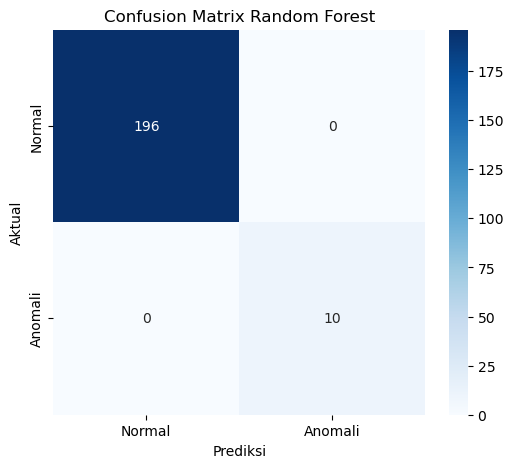

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Anomali"],
    yticklabels=["Normal","Anomali"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")

plt.show()

## Menghitung Accuracy, Precision, Recall, F1-Score

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## Classification Report

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       196
           1       1.00      1.00      1.00        10

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206



## Feature Importance

In [25]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,MAF,0.240963
5,LPH,0.225728
4,GPH,0.178387
7,CO2 Emissions,0.142633
6,KPL,0.131479
3,Speed,0.029180
0,lat,0.026599
1,lng,0.025031


## Visualisasi Feature Importance

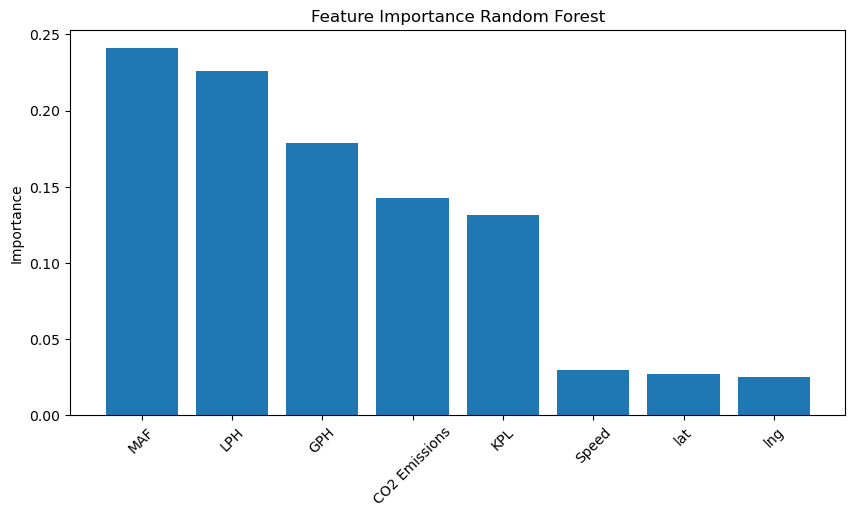

In [26]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance Random Forest")

plt.show()

## Menyimpan Model

In [27]:
joblib.dump(
    rf,
    "../model/randomforest.pkl"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


## Menyimpan Hasil Prediksi

In [28]:
df["RF_Prediction"] = rf.predict(X)

df.head()

,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions,Anomaly,Prediction,Anomaly Score,Label,RF_Prediction
0,0.478759,2.143419,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.379977,0,0
1,0.474486,2.079248,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.376475,0,0
2,0.480184,2.014739,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.375089,0,0
3,0.480997,1.977785,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.367951,0,0
4,0.504587,1.543742,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0,0,-0.354787,0,0


In [29]:
df.to_csv(
    "../Datasheet/OBD-Anomaly-Detection/dataset/randomforest_result.csv",
    index=False
)

print("Hasil prediksi berhasil disimpan.")

Hasil prediksi berhasil disimpan.
